In [1]:
import pandas as pd
from scipy.stats import norm
import numpy as np
import pyreadr
import itertools
import pingouin as pg
import itertools
import glob
import seaborn as sns
import os
import re
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt


In [2]:
df_controle = pd.read_csv(r"..\dados\raios_espectrais\raios_espectrais_SitioIdadeSexo_controle.csv")
df_autismo = pd.read_csv(r"..\dados\raios_espectrais\raios_espectrais_SitioIdadeSexo_autismo.csv")

In [3]:
df_controle.describe()

,Somatomotor,Visual,Default_mode,Cerebellar,Control
count,529.000000,529.000000,529.000000,529.000000,529.000000
mean,38.258393,31.335992,43.864592,22.120293,22.015975
std,9.274989,7.064236,9.947192,6.662150,4.866455
min,-0.333879,-0.206132,-0.305175,-0.368641,-0.045223
25%,33.285365,27.425110,38.101217,18.130509,19.382804
50%,38.994710,31.706984,44.973870,21.997813,22.210309
75%,44.576899,36.340256,50.232373,25.966045,25.262666
max,57.824371,48.048820,67.371140,40.677025,32.832227


In [4]:
df_autismo.describe()

,Somatomotor,Visual,Default_mode,Cerebellar,Control
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,35.477500,30.736035,40.741100,20.075884,20.352975
std,9.660354,7.419902,11.008025,6.970031,5.353892
min,0.172664,0.488696,0.327676,-0.078234,0.265152
25%,29.531524,26.762742,34.894633,15.961739,17.940825
50%,36.681162,30.627192,41.487946,19.684217,21.078999
75%,42.152542,35.259881,48.331537,24.765444,23.513021
max,55.848789,50.126532,65.649996,36.692001,32.225948


### Outliers

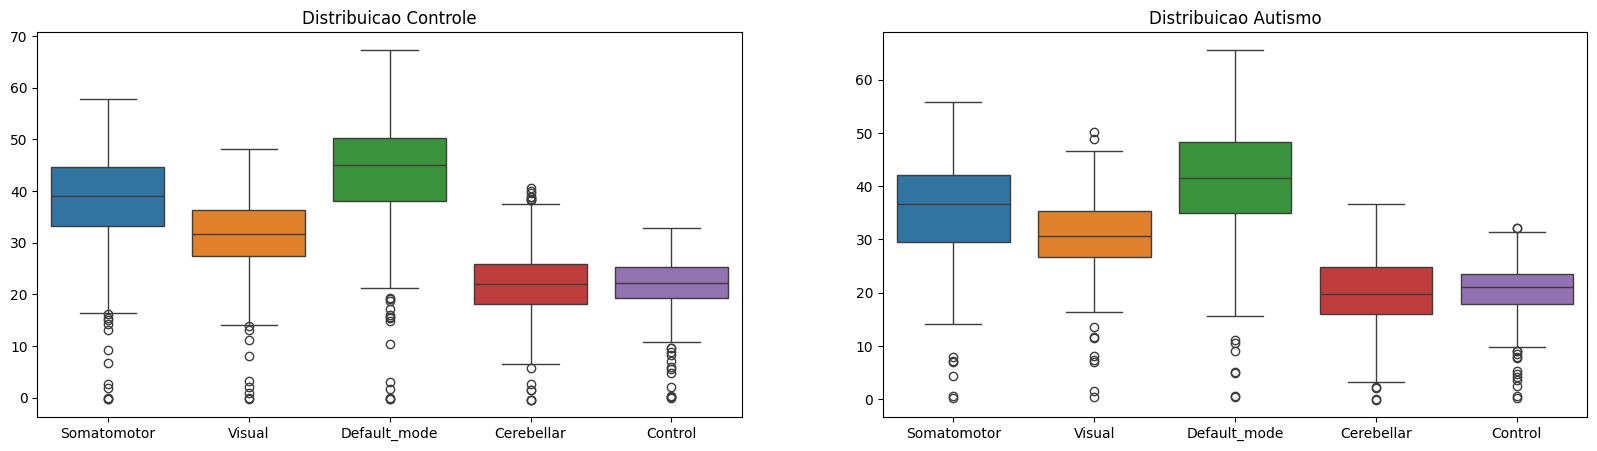

In [5]:
fig, ax = plt.subplots(ncols=2, nrows=1, sharex=False, sharey=False, figsize=(20, 5))
sns.boxplot(df_controle, ax=ax[0]);
sns.boxplot(df_autismo, ax=ax[1]);

ax[0].set_title("Distribuicao Controle")
ax[1].set_title("Distribuicao Autismo")
plt.show()

### Analisando correlações

#### 1) Correlações de Spearman

In [6]:

correlacoes_spearman_controle = pg.pairwise_corr(df_controle, method="spearman", padjust="fdr_bh", alternative="two-sided")
correlacoes_spearman_autismo = pg.pairwise_corr(df_autismo, method="spearman", padjust="fdr_bh", alternative="two-sided")

print("CORRELAÇÕES DE SPEARMAN PARA CONJUNTO CONTROLE")
display(correlacoes_spearman_controle)


print("\nCORRELAÇÕES DE SPEARMAN PARA CONJUNTO AUTISMO")
display(correlacoes_spearman_autismo)

CORRELAÇÕES DE SPEARMAN PARA CONJUNTO CONTROLE


,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,power
0,Somatomotor,Visual,spearman,two-sided,529,0.374335,"[0.3, 0.45]",4.854693e-19,8.091155e-19,fdr_bh,1.000000
1,Somatomotor,Default_mode,spearman,two-sided,529,0.399550,"[0.33, 0.47]",1.075556e-21,3.585188e-21,fdr_bh,1.000000
2,Somatomotor,Cerebellar,spearman,two-sided,529,0.382868,"[0.31, 0.45]",6.508139e-20,1.627035e-19,fdr_bh,1.000000
3,Somatomotor,Control,spearman,two-sided,529,0.445400,"[0.37, 0.51]",3.840425e-27,1.920212e-26,fdr_bh,1.000000
4,Visual,Default_mode,spearman,two-sided,529,0.360749,"[0.28, 0.43]",1.054874e-17,1.318592e-17,fdr_bh,1.000000
5,Visual,Cerebellar,spearman,two-sided,529,0.376650,"[0.3, 0.45]",2.831221e-19,5.662442e-19,fdr_bh,1.000000
6,Visual,Control,spearman,two-sided,529,0.363640,"[0.29, 0.44]",5.546611e-18,7.923730e-18,fdr_bh,1.000000
7,Default_mode,Cerebellar,spearman,two-sided,529,0.192214,"[0.11, 0.27]",8.505559e-06,8.505559e-06,fdr_bh,0.993927
8,Default_mode,Control,spearman,two-sided,529,0.493442,"[0.43, 0.56]",8.194685e-34,8.194685e-33,fdr_bh,1.000000
9,Cerebellar,Control,spearman,two-sided,529,0.349013,"[0.27, 0.42]",1.342168e-16,1.491298e-16,fdr_bh,1.000000



CORRELAÇÕES DE SPEARMAN PARA CONJUNTO AUTISMO


,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,power
0,Somatomotor,Visual,spearman,two-sided,285,0.460684,"[0.36, 0.55]",2.225060e-16,3.178657e-16,fdr_bh,1.000000
1,Somatomotor,Default_mode,spearman,two-sided,285,0.573045,"[0.49, 0.65]",2.834012e-26,9.446706e-26,fdr_bh,1.000000
2,Somatomotor,Cerebellar,spearman,two-sided,285,0.510215,"[0.42, 0.59]",2.713095e-20,5.426190e-20,fdr_bh,1.000000
3,Somatomotor,Control,spearman,two-sided,285,0.589019,"[0.51, 0.66]",5.226938e-28,2.613469e-27,fdr_bh,1.000000
4,Visual,Default_mode,spearman,two-sided,285,0.513301,"[0.42, 0.59]",1.471965e-20,3.679912e-20,fdr_bh,1.000000
5,Visual,Cerebellar,spearman,two-sided,285,0.410837,"[0.31, 0.5]",4.944114e-13,5.493460e-13,fdr_bh,1.000000
6,Visual,Control,spearman,two-sided,285,0.494436,"[0.4, 0.58]",5.621010e-19,9.368350e-19,fdr_bh,1.000000
7,Default_mode,Cerebellar,spearman,two-sided,285,0.281320,"[0.17, 0.38]",1.391804e-06,1.391804e-06,fdr_bh,0.998152
8,Default_mode,Control,spearman,two-sided,285,0.648785,"[0.58, 0.71]",1.944307e-35,1.944307e-34,fdr_bh,1.000000
9,Cerebellar,Control,spearman,two-sided,285,0.445220,"[0.35, 0.53]",2.785224e-15,3.481530e-15,fdr_bh,1.000000


#### 2) Correlações Parciais de Spearman dois-dois

In [7]:
def calcular_correlacoes_parciais(df, method='spearman', ajuste="fdr_bh", alpha=0.05):
    colunas = df.columns
    combinacoes = list(itertools.combinations(colunas, 2))
    correlacoes_parciais = pd.DataFrame()
    for col1, col2 in combinacoes:
        covariaveis = [i for i in colunas if i not in (col1, col2)]
        df_i = pg.pairwise_corr(df, method=method, alternative="two-sided", covar=covariaveis)
        correlacoes_parciais = pd.concat([correlacoes_parciais, df_i], ignore_index=True)

    reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-unc'].values, method=ajuste, alpha=alpha)

    # 3. Adicionamos os resultados ao DataFrame final
    correlacoes_parciais['p-corr'] = p_corr
    correlacoes_parciais['reject_h0'] = reject_h0

    return correlacoes_parciais

In [8]:
print("CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO CONTROLE")
correlacoes_parciais_controle = calcular_correlacoes_parciais(df_controle, method="spearman", ajuste="bonf", alpha=0.05)
display(correlacoes_parciais_controle)


print("\nCORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO AUTISMO")
correlacoes_parciais_autismo = calcular_correlacoes_parciais(df_autismo, method="spearman", ajuste="bonf", alpha=0.05)
display(correlacoes_parciais_autismo)


CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO CONTROLE


,X,Y,method,covar,alternative,n,r,CI95%,p-unc,p-corr,reject_h0
0,Somatomotor,Visual,spearman,"['Default_mode', 'Cerebellar', 'Control']",two-sided,529,0.147033,"[0.06, 0.23]",7.181968e-04,7.181968e-03,True
1,Somatomotor,Default_mode,spearman,"['Visual', 'Cerebellar', 'Control']",two-sided,529,0.198278,"[0.11, 0.28]",4.601156e-06,4.601156e-05,True
2,Somatomotor,Cerebellar,spearman,"['Visual', 'Default_mode', 'Control']",two-sided,529,0.225772,"[0.14, 0.31]",1.663989e-07,1.663989e-06,True
3,Somatomotor,Control,spearman,"['Visual', 'Default_mode', 'Cerebellar']",two-sided,529,0.214383,"[0.13, 0.29]",6.944272e-07,6.944272e-06,True
4,Visual,Default_mode,spearman,"['Somatomotor', 'Cerebellar', 'Control']",two-sided,529,0.190228,"[0.11, 0.27]",1.120003e-05,1.120003e-04,True
5,Visual,Cerebellar,spearman,"['Somatomotor', 'Default_mode', 'Control']",two-sided,529,0.244294,"[0.16, 0.32]",1.381227e-08,1.381227e-07,True
6,Visual,Control,spearman,"['Somatomotor', 'Default_mode', 'Cerebellar']",two-sided,529,0.106920,"[0.02, 0.19]",1.415172e-02,1.415172e-01,False
7,Default_mode,Cerebellar,spearman,"['Somatomotor', 'Visual', 'Control']",two-sided,529,-0.085136,"[-0.17, 0.0]",5.100121e-02,5.100121e-01,False
8,Default_mode,Control,spearman,"['Somatomotor', 'Visual', 'Cerebellar']",two-sided,529,0.354317,"[0.28, 0.43]",5.283361e-17,5.283361e-16,True
9,Cerebellar,Control,spearman,"['Somatomotor', 'Visual', 'Default_mode']",two-sided,529,0.180870,"[0.1, 0.26]",3.008992e-05,3.008992e-04,True



CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO AUTISMO


,X,Y,method,covar,alternative,n,r,CI95%,p-unc,p-corr,reject_h0
0,Somatomotor,Visual,spearman,"['Default_mode', 'Cerebellar', 'Control']",two-sided,285,0.079407,"[-0.04, 0.19]",1.836369e-01,1.000000e+00,False
1,Somatomotor,Default_mode,spearman,"['Visual', 'Cerebellar', 'Control']",two-sided,285,0.300599,"[0.19, 0.4]",2.675544e-07,2.675544e-06,True
2,Somatomotor,Cerebellar,spearman,"['Visual', 'Default_mode', 'Control']",two-sided,285,0.337139,"[0.23, 0.44]",6.349873e-09,6.349873e-08,True
3,Somatomotor,Control,spearman,"['Visual', 'Default_mode', 'Cerebellar']",two-sided,285,0.213008,"[0.1, 0.32]",3.151035e-04,3.151035e-03,True
4,Visual,Default_mode,spearman,"['Somatomotor', 'Cerebellar', 'Control']",two-sided,285,0.264223,"[0.15, 0.37]",6.874637e-06,6.874637e-05,True
5,Visual,Cerebellar,spearman,"['Somatomotor', 'Default_mode', 'Control']",two-sided,285,0.216755,"[0.1, 0.33]",2.449701e-04,2.449701e-03,True
6,Visual,Control,spearman,"['Somatomotor', 'Default_mode', 'Cerebellar']",two-sided,285,0.127353,"[0.01, 0.24]",3.252978e-02,3.252978e-01,False
7,Default_mode,Cerebellar,spearman,"['Somatomotor', 'Visual', 'Control']",two-sided,285,-0.181082,"[-0.29, -0.07]",2.268301e-03,2.268301e-02,True
8,Default_mode,Control,spearman,"['Somatomotor', 'Visual', 'Cerebellar']",two-sided,285,0.429253,"[0.33, 0.52]",4.529532e-14,4.529532e-13,True
9,Cerebellar,Control,spearman,"['Somatomotor', 'Visual', 'Default_mode']",two-sided,285,0.208887,"[0.09, 0.32]",4.135890e-04,4.135890e-03,True


#### 3) Comparação de correlações com Fisher Z test

In [9]:
def fisher_z_test(r1, r2, n1, n2):
    """
    Testa a diferença entre duas correlações independentes.
    
    Parâmetros:
    r1, r2: Coeficientes de correlação (ex: Controle e TEA)
    n1, n2: Tamanho das amostras dos respectivos grupos
    
    Retorna:
    Z-statistic, p-value
    """
    # Passo 1: Transformação r-to-z (arctanh é a mesma coisa que a fórmula do log)
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Passo 2: Calcular o Erro Padrão e a Estatística Z
    se = np.sqrt((1 / (n1 - 3)) + (1 / (n2 - 3)))
    z_stat = (z1 - z2) / se
    
    # Passo 3: Calcular o p-valor (teste bicaudal)
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))
    
    return p_value



def fisher_z_test_spearman(r1, r2, n1, n2):
    """
    Testa a diferença entre duas correlações independentes de Spearman, com correção para inflação
    de variância de rank (i.e., penalização do SE em 1.06).
    
    Parâmetros:
    r1, r2: Coeficientes de correlação de Spearman (ex: Controle e TEA)
    n1, n2: Tamanho das amostras dos respectivos grupos
    
    Retorna:
    p-value
    """
    # Passo 1: Transformação r-to-z (arctanh é a mesma coisa que a fórmula do log)
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Passo 2: Calcular o Erro Padrão com a penalidade matemática para Spearman (1.06)
    se = np.sqrt((1.06 / (n1 - 3)) + (1.06 / (n2 - 3)))
    
    # Calcular a estatística Z
    z_stat = (z1 - z2) / se
    
    # Passo 3: Calcular o p-valor (teste bicaudal)
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))

    return p_value

In [10]:
correlacoes = correlacoes_spearman_controle[["X", "Y", "r"]].copy().rename(columns={"r":"correlacoes_controle"})
correlacoes["correlacoes_autismo"] = correlacoes_spearman_autismo["r"]

In [11]:
correlacoes_parciais = correlacoes_parciais_controle[["X", "Y", "covar", "r"]]\
    .copy()\
    .rename(columns={"r":"correlacoes_controle"})

correlacoes_parciais["correlacoes_autismo"] = correlacoes_parciais_autismo["r"]

##### 3.1) Diferenca entre as correlacoes, utilizando SE sem penalidade

In [12]:
print("CORRELAÇÕES DE SPEARMAN")
correlacoes["p-value"] = correlacoes.apply(lambda x: fisher_z_test(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes["p-value-adj"] = p_corr
correlacoes

CORRELAÇÕES DE SPEARMAN


,X,Y,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,0.374335,0.460684,0.155923,0.194904
1,Somatomotor,Default_mode,0.399550,0.573045,0.001923,0.009617
2,Somatomotor,Cerebellar,0.382868,0.510215,0.030580,0.050966
3,Somatomotor,Control,0.445400,0.589019,0.007538,0.025126
4,Visual,Default_mode,0.360749,0.513301,0.010260,0.025649
5,Visual,Cerebellar,0.376650,0.410837,0.583482,0.583482
6,Visual,Control,0.363640,0.494436,0.029313,0.050966
7,Default_mode,Cerebellar,0.192214,0.281320,0.200503,0.222781
8,Default_mode,Control,0.493442,0.648785,0.001624,0.009617
9,Cerebellar,Control,0.349013,0.445220,0.121125,0.173036


- Somatomotor ~ Default_mode 
- Somatormotor ~  Control
- Visual ~ Default_mode
- Default_mode ~ Control

In [13]:
print("CORRELAÇÃO PARCIAL")
correlacoes_parciais["p-value"] = correlacoes_parciais.apply(lambda x: fisher_z_test(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes_parciais["p-value-adj"] = p_corr
correlacoes_parciais

CORRELAÇÃO PARCIAL


,X,Y,covar,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,"['Default_mode', 'Cerebellar', 'Control']",0.147033,0.079407,0.353119,0.588531
1,Somatomotor,Default_mode,"['Visual', 'Cerebellar', 'Control']",0.198278,0.300599,0.138849,0.574787
2,Somatomotor,Cerebellar,"['Visual', 'Default_mode', 'Control']",0.225772,0.337139,0.100753,0.574787
3,Somatomotor,Control,"['Visual', 'Default_mode', 'Cerebellar']",0.214383,0.213008,0.984431,0.984431
4,Visual,Default_mode,"['Somatomotor', 'Cerebellar', 'Control']",0.190228,0.264223,0.290157,0.580315
5,Visual,Cerebellar,"['Somatomotor', 'Default_mode', 'Control']",0.244294,0.216755,0.693502,0.865480
6,Visual,Control,"['Somatomotor', 'Default_mode', 'Cerebellar']",0.106920,0.127353,0.778932,0.865480
7,Default_mode,Cerebellar,"['Somatomotor', 'Visual', 'Control']",-0.085136,-0.181082,0.185324,0.574787
8,Default_mode,Control,"['Somatomotor', 'Visual', 'Cerebellar']",0.354317,0.429253,0.229915,0.574787
9,Cerebellar,Control,"['Somatomotor', 'Visual', 'Default_mode']",0.180870,0.208887,0.693121,0.865480


Nenhuma correlacao parcial teve diferenca.

##### 3.2) Diferenca entre as correlacoes, utilizando SE com penalidade

In [14]:
print("CORRELAÇÕES DE SPEARMAN")
correlacoes["p-value"] = correlacoes.apply(lambda x: fisher_z_test_spearman(
                                                        r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                            axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes["p-value-adj"] = p_corr
correlacoes

CORRELAÇÕES DE SPEARMAN


,X,Y,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,0.374335,0.460684,0.168149,0.210187
1,Somatomotor,Default_mode,0.399550,0.573045,0.002589,0.012945
2,Somatomotor,Cerebellar,0.382868,0.510215,0.035693,0.059489
3,Somatomotor,Control,0.445400,0.589019,0.009449,0.031496
4,Visual,Default_mode,0.360749,0.513301,0.012658,0.031646
5,Visual,Cerebellar,0.376650,0.410837,0.594337,0.594337
6,Visual,Control,0.363640,0.494436,0.034287,0.059489
7,Default_mode,Cerebellar,0.192214,0.281320,0.213734,0.237483
8,Default_mode,Control,0.493442,0.648785,0.002206,0.012945
9,Cerebellar,Control,0.349013,0.445220,0.132180,0.188829


- Somatomotor ~ Default_mode
- Somatomotor ~ Control
- Visual ~ Default_mode
- Default_mode ~ Control

In [15]:
print("CORRELAÇÃO PARCIAL")
correlacoes_parciais["p-value"] = correlacoes_parciais.apply(lambda x: fisher_z_test_spearman(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes_parciais["p-value-adj"] = p_corr
correlacoes_parciais

CORRELAÇÃO PARCIAL


,X,Y,covar,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,"['Default_mode', 'Cerebellar', 'Control']",0.147033,0.079407,0.367113,0.611855
1,Somatomotor,Default_mode,"['Visual', 'Cerebellar', 'Control']",0.198278,0.300599,0.150551,0.608461
2,Somatomotor,Cerebellar,"['Visual', 'Default_mode', 'Control']",0.225772,0.337139,0.110917,0.608461
3,Somatomotor,Control,"['Visual', 'Default_mode', 'Cerebellar']",0.214383,0.213008,0.984878,0.984878
4,Visual,Default_mode,"['Somatomotor', 'Cerebellar', 'Control']",0.190228,0.264223,0.304231,0.608461
5,Visual,Cerebellar,"['Somatomotor', 'Default_mode', 'Control']",0.244294,0.216755,0.701875,0.872358
6,Visual,Control,"['Somatomotor', 'Default_mode', 'Cerebellar']",0.106920,0.127353,0.785122,0.872358
7,Default_mode,Cerebellar,"['Somatomotor', 'Visual', 'Control']",-0.085136,-0.181082,0.198266,0.608461
8,Default_mode,Control,"['Somatomotor', 'Visual', 'Cerebellar']",0.354317,0.429253,0.243572,0.608461
9,Cerebellar,Control,"['Somatomotor', 'Visual', 'Default_mode']",0.180870,0.208887,0.701503,0.872358


Nenhuma correlacao parcial teve diferenca

### Atlas and ROIs, label verification 

In [16]:
def mapeamento_roi_cluster(cluster):
    df_labels = pd.read_csv(r"..\dados\CC400_ROI_labels.csv", 
                        sep=",", 
                        header=0
                        )
    labels_scrubbing = pyreadr.read_r(r"..\dados\labelsComScrubbing_Nclusters_collection\labelsComScrubbing_5clusters.RData")["labels"]

    rois_cluster_i = labels_scrubbing[labels_scrubbing["labels"] == cluster].index.values + 1
    nome_rois_cluster_i = df_labels[df_labels["ROI number"].isin(rois_cluster_i)]
    return nome_rois_cluster_i

In [17]:
rois_cluster_1 = mapeamento_roi_cluster(cluster=1)
rois_cluster_2 = mapeamento_roi_cluster(cluster=2)

In [18]:
rois_cluster_1

,ROI number,volume,center of mass,Dosenbach,AAL,Eickhoff-Zilles,Talairach-Tournoux,Harvard-Oxford
0,1,111,(-10.5;-49.4;-7.3),"[""None"": 0.94]","[""Cerebelum_4_5_L"": 0.64][""Lingual_L"": 0.29]","[""Left Cerebellum"": 0.67][""Left Lingual Gyrus""...","[""Left Culmen"": 0.82]","[""Left Lingual Gyrus"": 0.58][""None"": 0.30]"
16,17,73,(40.6;-62.7;-34.9),"[""None"": 0.96]","[""Cerebelum_Crus1_R"": 0.89][""Cerebelum_Crus2_R...","[""Right Cerebellum"": 0.47][""Right Cerebellum"":...","[""Right Cerebellar Tonsil"": 0.49][""Right Infer...","[""None"": 1.00]"
17,18,96,(-19.8;-69.3;-25.9),"[""None"": 0.90]","[""Cerebelum_6_L"": 0.60][""Cerebelum_Crus1_L"": 0...","[""Left Cerebellum"": 0.59][""Left Cerebellum"": 0...","[""Left Uvula"": 0.36][""Left Pyramis"": 0.30][""Le...","[""None"": 1.00]"
20,21,94,(-6.8;-11.6;10.9),"[""None"": 0.85][""thalamus"": 0.12]","[""Thalamus_L"": 0.91]","[""Left Thalamus"": 0.91]","[""Left Thalamus"": 0.95]","[""Left Thalamus"": 1.00]"
23,24,155,(-15.2;-91.6;-14.1),"[""None"": 1.00]","[""Lingual_L"": 0.43][""Cerebelum_Crus1_L"": 0.28]...","[""Left Lingual Gyrus"": 0.54][""Left Cerebellum""...","[""Left Lingual Gyrus"": 0.46][""Left Fusiform Gy...","[""Left Occipital Pole"": 0.40][""Left Occipital ..."
...,...,...,...,...,...,...,...,...
293,297,112,(-5.7;57.9;23.0),"[""None"": 0.99]","[""Frontal_Sup_Medial_L"": 0.89][""Frontal_Sup_L""...","[""Left Superior Medial Gyrus"": 0.88][""Left Sup...","[""Left Superior Frontal Gyrus"": 0.66][""Left Me...","[""Left Frontal Pole"": 0.57][""Left Superior Fro..."
300,304,106,(29.1;-4.5;53.2),"[""None"": 1.00]","[""Precentral_R"": 0.44][""Frontal_Mid_R"": 0.29][...","[""RightPrecentral Gyrus"": 0.53][""Right Superio...","[""Right Middle Frontal Gyrus"": 0.84][""Right Pr...","[""Right Precentral Gyrus"": 0.54][""Right Middle..."
301,305,142,(-57.5;-10.3;10.6),"[""None"": 0.97]","[""Temporal_Sup_L"": 0.39][""Rolandic_Oper_L"": 0....","[""Left Superior Temporal Gyrus"": 0.44][""Left R...","[""Left Superior Temporal Gyrus"": 0.41][""Left P...","[""Left Central Opercular Cortex"": 0.50][""Left ..."
306,310,96,(17.4;-41.1;-27.5),"[""None"": 1.00]","[""None"": 0.40][""Cerebelum_4_5_R"": 0.38][""Cereb...","[""None"": 0.42][""Right Cerebellum"": 0.24][""Righ...","[""Right Cerebellar Tonsil"": 0.43][""Right Culme...","[""None"": 0.96]"


In [19]:
rois_cluster_2

,ROI number,volume,center of mass,Dosenbach,AAL,Eickhoff-Zilles,Talairach-Tournoux,Harvard-Oxford
1,2,110,(28.6;55.2;18.2),"[""None"": 0.82][""aPFC"": 0.17]","[""Frontal_Sup_R"": 0.51][""Frontal_Mid_R"": 0.49]","[""Right Superior Frontal Gyrus"": 0.64][""Right ...","[""Right Superior Frontal Gyrus"": 0.54][""Right ...","[""Right Frontal Pole"": 1.00]"
14,15,117,(45.6;20.2;38.8),"[""None"": 0.83][""dFC"": 0.15]","[""Frontal_Mid_R"": 0.75][""Frontal_Inf_Oper_R"": ...","[""Right Middle Frontal Gyrus"": 0.58][""Right In...","[""Right Middle Frontal Gyrus"": 0.77][""Right Pr...","[""Right Middle Frontal Gyrus"": 1.00]"
22,23,108,(59.8;-5.2;29.0),"[""None"": 0.93]","[""Postcentral_R"": 0.85][""Precentral_R"": 0.15]","[""Right Postcentral Gyrus"": 0.79][""RightPrecen...","[""Right Precentral Gyrus"": 0.93]","[""Right Precentral Gyrus"": 0.51][""Right Postce..."
27,28,125,(-8.4;-16.1;71.9),"[""None"": 1.00]","[""Paracentral_Lobule_L"": 0.56][""Supp_Motor_Are...","[""Left Paracentral Lobule"": 0.72][""Left SMA"": ...","[""None"": 0.63][""Left Medial Frontal Gyrus"": 0.23]","[""Left Precentral Gyrus"": 0.71][""Left Juxtapos..."
33,35,147,(-38.0;-29.4;56.3),"[""None"": 0.83][""parietal"": 0.12]","[""Postcentral_L"": 0.78][""Precentral_L"": 0.21]","[""Left Postcentral Gyrus"": 0.82][""Left Precent...","[""Left Postcentral Gyrus"": 0.66][""Left Precent...","[""Left Postcentral Gyrus"": 0.88][""Left Precent..."
48,50,69,(-0.9;-20.4;-12.3),"[""None"": 1.00]","[""None"": 1.00]","[""None"": 0.97]","[""None"": 1.00]","[""None"": 1.00]"
50,52,127,(52.9;-36.9;4.9),"[""None"": 0.86][""temporal"": 0.14]","[""Temporal_Mid_R"": 0.59][""Temporal_Sup_R"": 0.41]","[""Right Middle Temporal Gyrus"": 0.82][""Right S...","[""Right Middle Temporal Gyrus"": 0.61][""Right S...","[""Right Superior Temporal Gyrus; posterior div..."
55,57,116,(-62.8;-36.4;-6.2),"[""None"": 0.88][""inf temporal"": 0.12]","[""Temporal_Mid_L"": 1.00]","[""Left Middle Temporal Gyrus"": 0.99]","[""Left Middle Temporal Gyrus"": 0.99]","[""Left Middle Temporal Gyrus; posterior divisi..."
68,70,136,(28.3;-74.8;-13.8),"[""None"": 0.98]","[""Fusiform_R"": 0.57][""Cerebelum_6_R"": 0.32]","[""Right Fusiform Gyrus"": 0.40][""Right Cerebell...","[""Right Declive"": 0.50][""Right Fusiform Gyrus""...","[""Right Occipital Fusiform Gyrus"": 0.83][""None..."
69,71,93,(4.3;-17.3;-2.6),"[""None"": 0.96]","[""Thalamus_R"": 0.51][""None"": 0.32][""Thalamus_L...","[""None"": 0.60][""Right Thalamus"": 0.30]","[""None"": 0.62][""Right Thalamus"": 0.32]","[""Right Thalamus"": 0.51][""None"": 0.30][""Left T..."
